<a href="https://www.kaggle.com/code/shravankumarpandey/upsc-essay-evaluation-workflow?scriptVersionId=335643498" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")

In [5]:
pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


# 1.Importing Libraries

In [7]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from pydantic import Field,BaseModel
import operator

# 2.Defining State and Model

## 2.1 Defining Large Language Model

In [8]:
llm=llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=secret_value_0
)

In [9]:
class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Detailed Feedback for essay")
    score:float=Field(description="Score out of 10",ge=0,le=10)

In [10]:
model=llm.with_structured_output(EvaluationSchema)

## 2.2 Defining State

In [11]:
class UPSC_Evaluation_State(TypedDict):
    essay:str
    cot_feedback:str
    doa_feedback:str
    language_feedback:str
    individual_score:Annotated[list[float],operator.add]
    final_feedback:str
    final_score:float

# 3.Defining Node

## 3.1 Adding Clarity of Thought(COT) Node

In [12]:
def evaluate_cot_node(state:UPSC_Evaluation_State)->UPSC_Evaluation_State:
    prompt=f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"
    output=model.invoke(prompt)
    return {
        "cot_feedback":output.feedback,
        "individual_score":[output.score]
    }
    

## 3.2 Adding Depth of Analysis(DOA) Node

In [13]:
def evaluate_doa_node(state:UPSC_Evaluation_State)->UPSC_Evaluation_State:
    prompt=f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"
    output=model.invoke(prompt)
    return {
        "doa_feedback":output.feedback,
        "individual_score":[output.score]
    }
    

## 3.3 Adding Language Evaluation Node

In [14]:
def evaluate_language_node(state:UPSC_Evaluation_State)->UPSC_Evaluation_State:
    prompt=f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"
    output=model.invoke(prompt)
    return {
        "language_feedback":output.feedback,
        "individual_score":[output.score]
    }

## 3.4 Adding Final Evaluation Node

In [15]:
def final_evaluation_node(state:UPSC_Evaluation_State)->UPSC_Evaluation_State:
    #Summary Feedback
    prompt=f'Based on the following feedbacks create a summarized feedback \n language feedback-{state["language_feedback"]} \n clarity of thought feedback-{state["cot_feedback"]} \n depth of analysis feedback-{state["doa_feedback"]}'
    overall_feedback=model.invoke(prompt).feedback

    # Calculate Average
    final_score=sum(state["individual_score"])/len(state["individual_score"])

    return {
        "final_feedback":overall_feedback,
        "final_score":final_score
    }

# 4.Initialize the Graph

## 4.1 Defining Node

In [16]:
graph=StateGraph(UPSC_Evaluation_State)

## 4.2 Adding Node

In [17]:
graph.add_node("evaluate_cot_node",evaluate_cot_node)
graph.add_node("evaluate_doa_node",evaluate_doa_node)
graph.add_node("evaluate_language_node",evaluate_language_node)
graph.add_node("final_evaluation_node",final_evaluation_node)

## 4.3 Adding Edges

### 4.3.1 Adding Parallel Edges

In [18]:
graph.add_edge(START,"evaluate_cot_node")
graph.add_edge(START,"evaluate_doa_node")
graph.add_edge(START,"evaluate_language_node")

### 4.3.2 Convergence of Parallel Edges

In [19]:
graph.add_edge("evaluate_cot_node","final_evaluation_node")
graph.add_edge("evaluate_doa_node","final_evaluation_node")
graph.add_edge("evaluate_language_node","final_evaluation_node")
graph.add_edge("final_evaluation_node",END)

# 5.Compilation

In [20]:
workflow=graph.compile()

## 5.1 Visualizing the Workflow

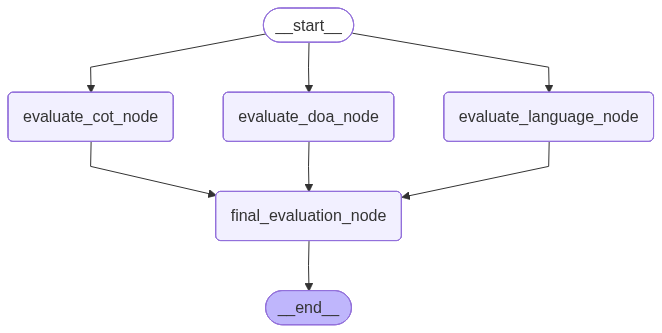

In [21]:
workflow

# Essay

# 6.Initial State

In [22]:
essay = """India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""

In [23]:
initial_state={
    "essay":essay
}

# 7.Execution

In [24]:
result=workflow.invoke(initial_state)

# 8. Final Result

In [25]:
print("Language Feedback: ",result["language_feedback"])

Language Feedback:  The essay demonstrates a strong understanding of the topic, with a clear and well-structured argument. The writer provides a comprehensive overview of India's strengths and challenges in the AI domain, and offers concrete examples of AI applications in various sectors. The language is formal and sophisticated, with proper use of technical terms and concepts. However, there are some areas for improvement, such as providing more nuanced analysis of the challenges and limitations of AI adoption in India, and offering more specific policy recommendations. Additionally, some sentences are quite long and convoluted, which can make them difficult to follow. Overall, the essay demonstrates a high level of language quality, with a score of 9 out of 10.


In [26]:
print("Clarity of Thought Feedback: ",result["cot_feedback"])

Clarity of Thought Feedback:  The essay provides a clear and well-structured overview of India's position in the age of AI, highlighting both the opportunities and challenges. The writer demonstrates a good understanding of the subject matter, providing relevant examples and statistics to support their arguments. The language is clear and concise, making it easy to follow the writer's train of thought. However, there are some areas where the essay could be improved, such as providing more concrete solutions to the challenges posed by AI and exploring the potential risks and biases associated with AI systems in more depth. Additionally, the essay could benefit from a more nuanced discussion of the ethical implications of AI adoption in India. Overall, the essay demonstrates a good clarity of thought, but could be further enhanced with more detailed analysis and critical thinking.


In [27]:
print("Depth of Analysis Feedback: ",result["doa_feedback"])

Depth of Analysis Feedback:  The essay provides a comprehensive analysis of India's position in the age of AI, highlighting both the opportunities and challenges. The writer demonstrates a good understanding of the subject, citing relevant examples and statistics to support their arguments. The essay is well-structured, with a clear introduction, body, and conclusion. However, the depth of analysis could be improved by providing more nuanced and critical perspectives on the issues discussed. Additionally, the writer could have explored more specific and detailed solutions to the challenges posed by AI. Overall, the essay demonstrates a good level of analysis, but could benefit from more depth and complexity in its arguments.


In [28]:
print("Final Feedback:",result["final_feedback"])

Final Feedback: The essay demonstrates a strong understanding of India's position in the age of AI, with a clear and well-structured argument. However, areas for improvement include providing more nuanced analysis of challenges, offering specific policy recommendations, and exploring potential risks and biases associated with AI systems. The essay could also benefit from a more nuanced discussion of ethical implications and more detailed analysis and critical thinking. The language is formal and sophisticated, but some sentences are long and convoluted. Overall, the essay demonstrates a high level of language quality, good clarity of thought, and good depth of analysis, but could be further enhanced with more detailed and nuanced perspectives.


In [29]:
print("Individual Score: ",result["individual_score"])

Individual Score:  [8.0, 8.0, 9.0]


In [30]:
print("Final Score: ",result["final_score"]," out of 10")

Final Score:  8.333333333333334  out of 10


# 9.Testing Other Essay

In [31]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [32]:
initial_state={
    "essay":essay2
}

In [33]:
result=workflow.invoke(initial_state)

In [34]:
print("Language Feedback:",result["language_feedback"])

Language Feedback: The essay demonstrates a clear understanding of the impact of AI on India, highlighting both the benefits and challenges. However, the language quality is simplistic, with short sentences and basic vocabulary. The writer could improve by using more complex sentence structures, varied vocabulary, and proper grammar. Additionally, there are some grammatical errors and awkward phrasing, such as 'Artificial Intel… something (AI)' and 'India go back.' The essay could also benefit from more nuanced and detailed analysis of the topics discussed. Overall, the essay shows promise, but requires further development in terms of language quality and depth of analysis.


In [35]:
print("Clarity of Thought Feedback:",result["cot_feedback"])

Clarity of Thought Feedback: The essay demonstrates a clear understanding of the impact of AI on India, highlighting both the benefits and drawbacks. However, the clarity of thought is sometimes compromised by simplistic language and sentence structures. The writer jumps abruptly between ideas and lacks cohesive transitions between paragraphs. Additionally, the essay could benefit from more nuanced and detailed analysis of the issues discussed. The writer's conclusions are somewhat vague and lack concrete recommendations for addressing the challenges posed by AI. Overall, the essay shows promise but requires more development and refinement to effectively convey the writer's thoughts.


In [36]:
print("Depth of Analysis Feedback:",result["doa_feedback"])

Depth of Analysis Feedback: The essay provides a basic overview of the impact of AI on India, highlighting both the benefits and drawbacks. The writer identifies key areas where AI can be applied, such as farming, healthcare, and education, and also touches upon the challenges of accessibility, job loss, and privacy. However, the analysis lacks depth and nuance, with oversimplifications and vague statements. The writer could have provided more concrete examples, data, and expert opinions to support their claims. Additionally, the essay could benefit from a clearer structure, more cohesive paragraphs, and improved grammar and vocabulary. Overall, the essay demonstrates a good effort but requires more development and refinement to achieve a higher level of analysis and argumentation.


In [37]:
print("Final Feedback:",result["final_feedback"])

Final Feedback: The essay demonstrates a clear understanding of the impact of AI on India but requires improvement in language quality, clarity of thought, and depth of analysis. It lacks complex sentence structures, varied vocabulary, and proper grammar, with some grammatical errors and awkward phrasing. The writer jumps abruptly between ideas, lacks cohesive transitions, and provides vague conclusions. The analysis is basic, lacking concrete examples, data, and expert opinions. To improve, the writer should focus on developing more nuanced and detailed analysis, using improved language quality, and providing concrete recommendations.


In [38]:
print("Individual Score:",result["individual_score"])

Individual Score: [6.0, 6.0, 6.0]


In [39]:
print("Final Score: ",result["final_score"]," out of 10")

Final Score:  6.0  out of 10
